In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import tabulate as tabulate

In [3]:
df = pd.read_excel('../Dataset/Credir_Card_Bank.xlsx')

In [4]:
df

,Customer_ID,Age,Gender,Employment_Type,Occupation,Monthly_Income,Annual_Income,Credit_Score,Years_With_Bank,Existing_Credit_Cards,...,Credit_Utilization,Credit_History_Years,Missed_Payments,Late_Payment_Count,Number_of_Defaults,Residential_Status,PAN_Verified,KYC_Status,Fraud_Flag,Credit_Limit
0,CUST00001,41,Female,Salaried,Sales Executive,140273,1683276,811,4,4,...,34,11,0,8,0,Rent,Yes,Complete,No,1373925
1,CUST00002,23,Male,Self-Employed,Business Owner,209521,2514252,837,12,2,...,71,20,3,3,0,Own,Yes,Complete,No,1902449
2,CUST00003,45,Female,Salaried,Designer,47682,572184,679,2,6,...,88,12,5,2,0,Rent,Yes,Complete,No,1165913
3,CUST00004,39,Male,Salaried,Doctor,214966,2579592,660,5,0,...,66,4,3,5,0,Rent,Yes,Complete,No,1869491
4,CUST00005,58,Male,Self-Employed,Designer,30051,360612,589,18,0,...,70,1,4,2,0,Own,Yes,Complete,No,825275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST04996,48,Male,Salaried,Doctor,55078,660936,824,12,1,...,91,7,4,4,0,Rent,Yes,Complete,No,1156917
4996,CUST04997,59,Female,Self-Employed,Accountant,107040,1284480,840,0,1,...,28,22,1,6,0,Own,Yes,Complete,No,1458578
4997,CUST04998,26,Female,Salaried,Doctor,168754,2025048,632,19,0,...,38,11,3,1,0,Rent,Yes,Complete,No,1342610
4998,CUST04999,42,Male,Salaried,Manager,197110,2365320,734,9,2,...,15,3,2,2,0,Own,Yes,Complete,No,1868828


In [5]:
df.iloc[:,10:-10]

,Existing_Credit_Limit,Loan_Count,EMI_Per_Month,Debt_To_Income_Ratio,Savings_Balance,Investment_Value,Avg_Monthly_Transactions,Avg_Monthly_Spending
0,706088,3,49141,0.33,221285,248294,221,69992.0
1,527133,1,13338,0.24,348033,1197179,199,17170.0
2,281776,1,3618,0.18,603413,1459090,76,16871.0
3,656977,0,16114,0.05,1113302,1362180,112,193469.4
4,267892,4,36361,0.32,824809,595409,46,6024.0
...,...,...,...,...,...,...,...,...
4995,806871,4,34469,0.10,433388,77558,211,30151.0
4996,896965,4,40182,0.25,254850,1934214,61,86594.0
4997,712921,1,52001,0.09,91677,868069,210,42256.0
4998,91279,1,40678,0.13,1256605,1989152,49,177399.0


# Customer Behavior Analysis

# 1. Analyze Spending Patterns

In [6]:
df['Avg_Monthly_Spending'].describe()

count      5000.000000
mean      70505.559160
std       52659.118896
min        5036.000000
25%       27080.500000
50%       56859.500000
75%      103339.750000
max      223764.300000
Name: Avg_Monthly_Spending, dtype: float64

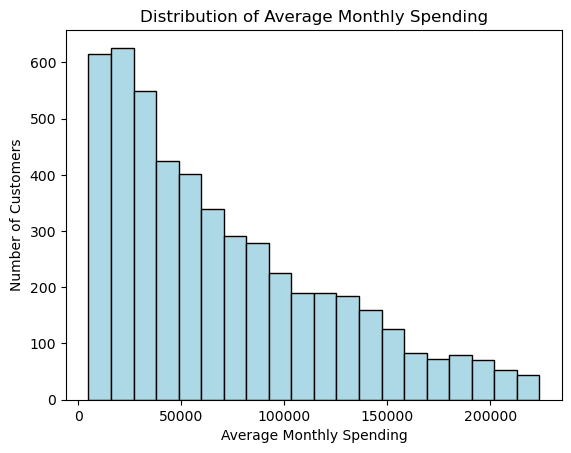

In [7]:
plt.hist(df['Avg_Monthly_Spending'], bins=20, edgecolor='black', color='Lightblue')

plt.title('Distribution of Average Monthly Spending')
plt.xlabel('Average Monthly Spending')
plt.ylabel('Number of Customers')

plt.show()

## Business Insights:
#### Monthly spending is distributed across customers with noticeable differences between low, medium, and high spenders.
 
#### A few customers have significantly higher spending, indicating premium customer segments.

# 2. Analyze Transaction Frequency

In [8]:
df['Avg_Monthly_Transactions'].describe()

count    5000.000000
mean      131.580000
std        69.399242
min        10.000000
25%        70.000000
50%       133.000000
75%       191.000000
max       250.000000
Name: Avg_Monthly_Transactions, dtype: float64

### On average, each customer performs 131 transactions per month

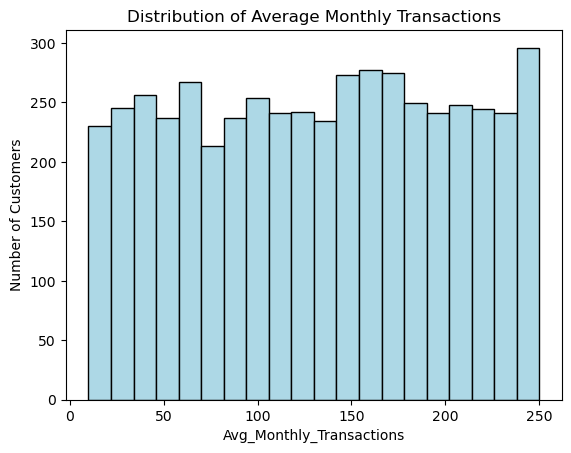

In [9]:
plt.hist(df['Avg_Monthly_Transactions'], bins=20, edgecolor='black', color='Lightblue')

plt.title('Distribution of Average Monthly Transactions')
plt.xlabel('Avg_Monthly_Transactions')
plt.ylabel('Number of Customers')

plt.show()

In [10]:
most_active = df.groupby ('Customer_ID')['Avg_Monthly_Transactions'].mean().nlargest(10)
most_active 

Customer_ID
CUST00295    250.0
CUST00489    250.0
CUST01051    250.0
CUST01550    250.0
CUST01894    250.0
CUST02621    250.0
CUST02946    250.0
CUST03066    250.0
CUST03099    250.0
CUST03315    250.0
Name: Avg_Monthly_Transactions, dtype: float64

### These customers: Frequently use banking services, Are highly engaged, May be good candidates for premium products or loyalty programs.

In [11]:
least_active = df.groupby('Customer_ID')['Avg_Monthly_Transactions'].mean().nsmallest(10)
least_active

Customer_ID
CUST00277    10.0
CUST00687    10.0
CUST01121    10.0
CUST01619    10.0
CUST02249    10.0
CUST02467    10.0
CUST02627    10.0
CUST02681    10.0
CUST03325    10.0
CUST03339    10.0
Name: Avg_Monthly_Transactions, dtype: float64

### These customers:Use banking services infrequently, May need targeted engagement or retention campaigns.

## Business Insight
  #### Most Active Customers: More than 191 transactions/month (top 25%).
  #### Average Customers: Around 132 transactions/month.
  #### Least Active Customers: Around 10–70 transactions/month (bottom 25%).

# 3. Compare Spending by Age Groups

In [12]:
# Function to create Age Groups
def age_group(age):
    if age < 20:
        return "Teen"
    elif age < 30:
        return "Young Adult"
    elif age < 50:
        return "Adult"
    elif age < 60:
        return "Middle Aged"
    else:
        return "Senior Citizen"

# Apply function
df['Age_Group'] = df['Age'].apply(age_group)

In [13]:
age_spending = df.groupby('Age_Group')['Avg_Monthly_Spending'].mean()


In [14]:
age_spending

Age_Group
Adult             69847.051641
Middle Aged       70125.005789
Senior Citizen    78816.913084
Young Adult       71595.078307
Name: Avg_Monthly_Spending, dtype: float64

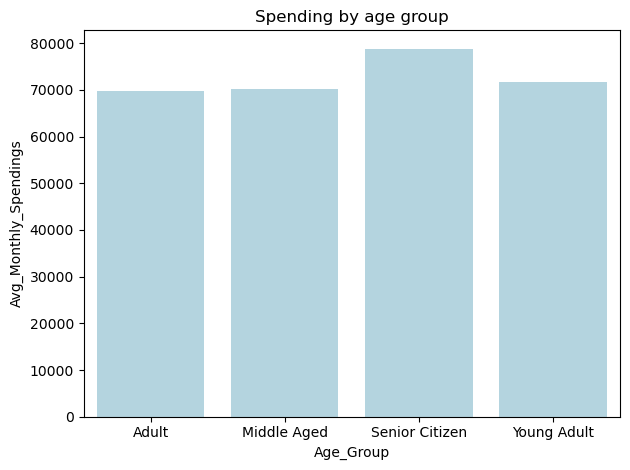

In [28]:
sb.barplot(age_spending, color = 'Lightblue')

plt.title('Spending by age group')
plt.xlabel('Age_Group')
plt.ylabel('Avg_Monthly_Spendings')
plt.tight_layout()
plt.show()

## Business Insight:
  #### The age-wise spending analysis indicates that Senior Citizens have the highest average monthly spending (₹78,816.91), followed by Young Adults (₹71,595.08).Adults and Middle-Aged customers have nearly identical spending levels, at ₹69,847.05 and ₹70,125.01 respectively.
  #### Adults and Middle-Aged customers demonstrate stable spending behavior, making them suitable targets for long-term financial products and personalized banking services.
  #### Overall, spending remains relatively stable across most age groups, while Senior Citizens represent a distinct high-spending segment that could be targeted with premium banking and investment services.

# 4. Compare Spending by Occupation

In [ ]:
o= df.groupby('Occupation')['Avg_Monthly_Spending'].mean().sort_values(ascending=False)
o

In [ ]:
sb.barplot(o, color = 'Lightblue')

plt.title('Spending by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Avg_Monthly_Spendings')
plt.xticks(rotation=90)
plt.show()

## Business Insight:
  #### Teachers and Accountants represent the highest-spending occupational groups in this dataset.
  #### Managers have the lowest average monthly spending, although the difference compared to other occupations is not very large.
  #### The variation in average spending across occupations is approximately ₹4,438 (₹72,514 − ₹68,076), suggesting that occupation has only a moderate influence on spending behavior in this dataset.
  #### Since spending differences are relatively small, the bank may benefit from combining occupation with other factors such as income, credit score, or employment type for more effective customer segmentation

# 5. Compare Spending by Employment Type

In [ ]:
e = df.groupby('Employment_Type')['Avg_Monthly_Spending'].mean()
e

In [ ]:
sb.barplot(e, color='pink')

plt.title('Spending by Employment Type')
plt.xlabel('Employment_Type')
plt.ylabel('Avg_Monthly_Spendings')
plt.xticks(rotation=90)
plt.show()

## Business Insight
  #### Both Salaried and Self-Employed customers exhibit almost identical spending behavior.
  #### Salaried customers spend only slightly more on average than Self-Employed customers.
  #### Since the difference is minimal, employment type alone does not appear to significantly influence monthly spending in this dataset.
  #### To better understand customer spending patterns, the bank should also consider other factors such as annual income, credit score, age, occupation, and savings balance.

# 6. Identify High-Value Customers

In [ ]:
# Calculate the 75th percentile values
income_threshold = df['Annual_Income'].quantile(0.75)
credit_limit_threshold = df['Credit_Limit'].quantile(0.75)

# Select high-value customers
high_value = df[
    (df['Annual_Income'] > income_threshold) &
    (df['Credit_Limit'] > credit_limit_threshold)
]

high_value



## Business Insights:
#### High-value customers have high income and high credit limits, making them ideal candidates for premium banking services, investment products, and personalized relationship management to maximize long-term profitability.

# 9. Low-Engagement Customers

In [ ]:
transaction_threshold = df['Avg_Monthly_Transactions'].quantile(0.25)
spending_threshold = df['Avg_Monthly_Spending'].quantile(0.25)

# Select low-engagement customers
low_engagement = df[
    (df['Avg_Monthly_Transactions'] < transaction_threshold) &
    (df['Avg_Monthly_Spending'] < spending_threshold)
]


low_engagement

## Business Insights:
#### Low-engagement customers are the least active users of banking services and should be targeted with personalized offers, loyalty programs, and product recommendations to increase their transaction frequency and spending.

# Customer Behaviour Analysis Dashboard

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20,16))

# 1. Histogram
plt.subplot(2,3,1)

plt.hist(df['Avg_Monthly_Spending'],
         bins=20,
         edgecolor='black',
         color='skyblue')

plt.title("Monthly Spending Distribution")
plt.xlabel("Monthly Spending")
plt.ylabel("Number of Customers")


# 2. Spending by Age Group
plt.subplot(2,3,2)

age = df.groupby('Age_Group', observed=True)['Avg_Monthly_Spending'].mean()

age.plot(kind='bar',
         color='mediumseagreen')

plt.title("Average Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Spending")


# 3. Spending by Occupation
plt.subplot(2,3,3)

occupation = df.groupby('Occupation')['Avg_Monthly_Spending'].mean()

occupation.sort_values().plot(kind='barh',
                              color='coral')

plt.title("Average Spending by Occupation")
plt.xlabel("Average Spending")


# 4. Spending by Employment Type
plt.subplot(2,3,4)

employment = df.groupby('Employment_Type')['Avg_Monthly_Spending'].mean()

employment.plot(kind='bar',
                color='gold')

plt.title("Average Spending by Employment Type")
plt.ylabel("Average Spending")


# 5. Top 10 High Spending Customers
plt.subplot(2,3,5)

top10 = df.nlargest(10,'Avg_Monthly_Spending')

plt.bar(top10['Customer_ID'],
        top10['Avg_Monthly_Spending'],
        color='orchid')

plt.xticks(rotation=90)

plt.title("Top 10 High Spending Customers")


# 6. Income vs Monthly Spending
plt.subplot(2,3,6)

plt.scatter(df['Annual_Income'],
            df['Avg_Monthly_Spending'],
            color='red',
            alpha=0.6)

plt.title("Income vs Monthly Spending")
plt.xlabel("Annual Income")
plt.ylabel("Monthly Spending")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


# Spending Analysis Dashboard

In [ ]:
# Function to create Age Groups
def age_group(age):
    if age < 20:
        return "Teen"
    elif age < 30:
        return "Young Adult"
    elif age < 50:
        return "Adult"
    elif age < 60:
        return "Middle Aged"
    else:
        return "Senior Citizen"

# Apply function
df['Age_Group'] = df['Age'].apply(age_group)

In [ ]:
# EMI Group
df['EMI_Group'] = pd.cut(df['EMI_Per_Month'],bins=5,labels=['Very Low EMI','Low EMI','Medium EMI','High EMI','Very High EMI'])

In [ ]:
# Debt-to-Income Ratio Group
df['DTI_Group'] = pd.cut(df['Debt_To_Income_Ratio'],bins=5,labels=['Very Low DTI','Low DTI','Medium DTI','High DTI','Very High DTI'])

In [ ]:
# Savings Balance Group
df['Savings_Group'] = pd.cut(df['Savings_Balance'],bins=5,labels=['Very Low Savings','Low Savings','Medium Savings','High Savings','Very High Savings'])

In [ ]:
# Investment Value Group
df['Investment_Group'] = pd.cut(df['Investment_Value'],bins=5,labels=['Very Low Investment','Low Investment','Medium Investment','High Investment','Very High Investment'])

In [ ]:
# Monthly Transactions Group
df['Transaction_Group'] = pd.cut(df['Avg_Monthly_Transactions'],bins=5,labels=['Very Low Transactions','Low Transactions','Medium Transactions','High Transactions','Very High Transactions'])

In [ ]:
# Credit Utilization Group
df['Utilization_Group'] = pd.cut(df['Credit_Utilization'],bins=5,labels=['Very Low Utilization','Low Utilization','Medium Utilization','High Utilization','Very High Utilization'])

In [26]:
plt.figure(figsize=(18,12))

# Step 1: Select Employment Type
print("Available Employment Types:")
print(df['Employment_Type'].unique())

emp = input("Enter Employment Type: ")

emp_df = df[df['Employment_Type'] == emp]

# Step 2: Select Occupation
print("Available Occupations:")
print(emp_df['Occupation'].unique())

occ = input("Enter Occupation: ")

occ_df = emp_df[emp_df['Occupation'] == occ]

# Step 3: Select Age Group
print("Available Age Groups:")
print(occ_df['Age_Group'].unique())


age = input("Enter Age Group: ")

final_df = occ_df[occ_df['Age_Group'] == age]

# Step 4: Spending Analysis
print("\nSpending Statistics")
print(final_df['Avg_Monthly_Spending'].describe())



Available Employment Types:
['Salaried' 'Self-Employed']


Enter Employment Type:  Salaried


Available Occupations:
['Sales Executive' 'Designer' 'Doctor' 'Accountant' 'Teacher'
 'Software Engineer' 'Business Owner' 'Manager']


Enter Occupation:  Doctor


Available Age Groups:
['Adult' 'Young Adult' 'Middle Aged' 'Senior Citizen']


Enter Age Group:  Young Adult



Spending Statistics
count        75.000000
mean      70170.557333
std       51000.939162
min        6587.000000
25%       28270.000000
50%       57152.000000
75%      104003.500000
max      213970.500000
Name: Avg_Monthly_Spending, dtype: float64


<Figure size 1800x1200 with 0 Axes>

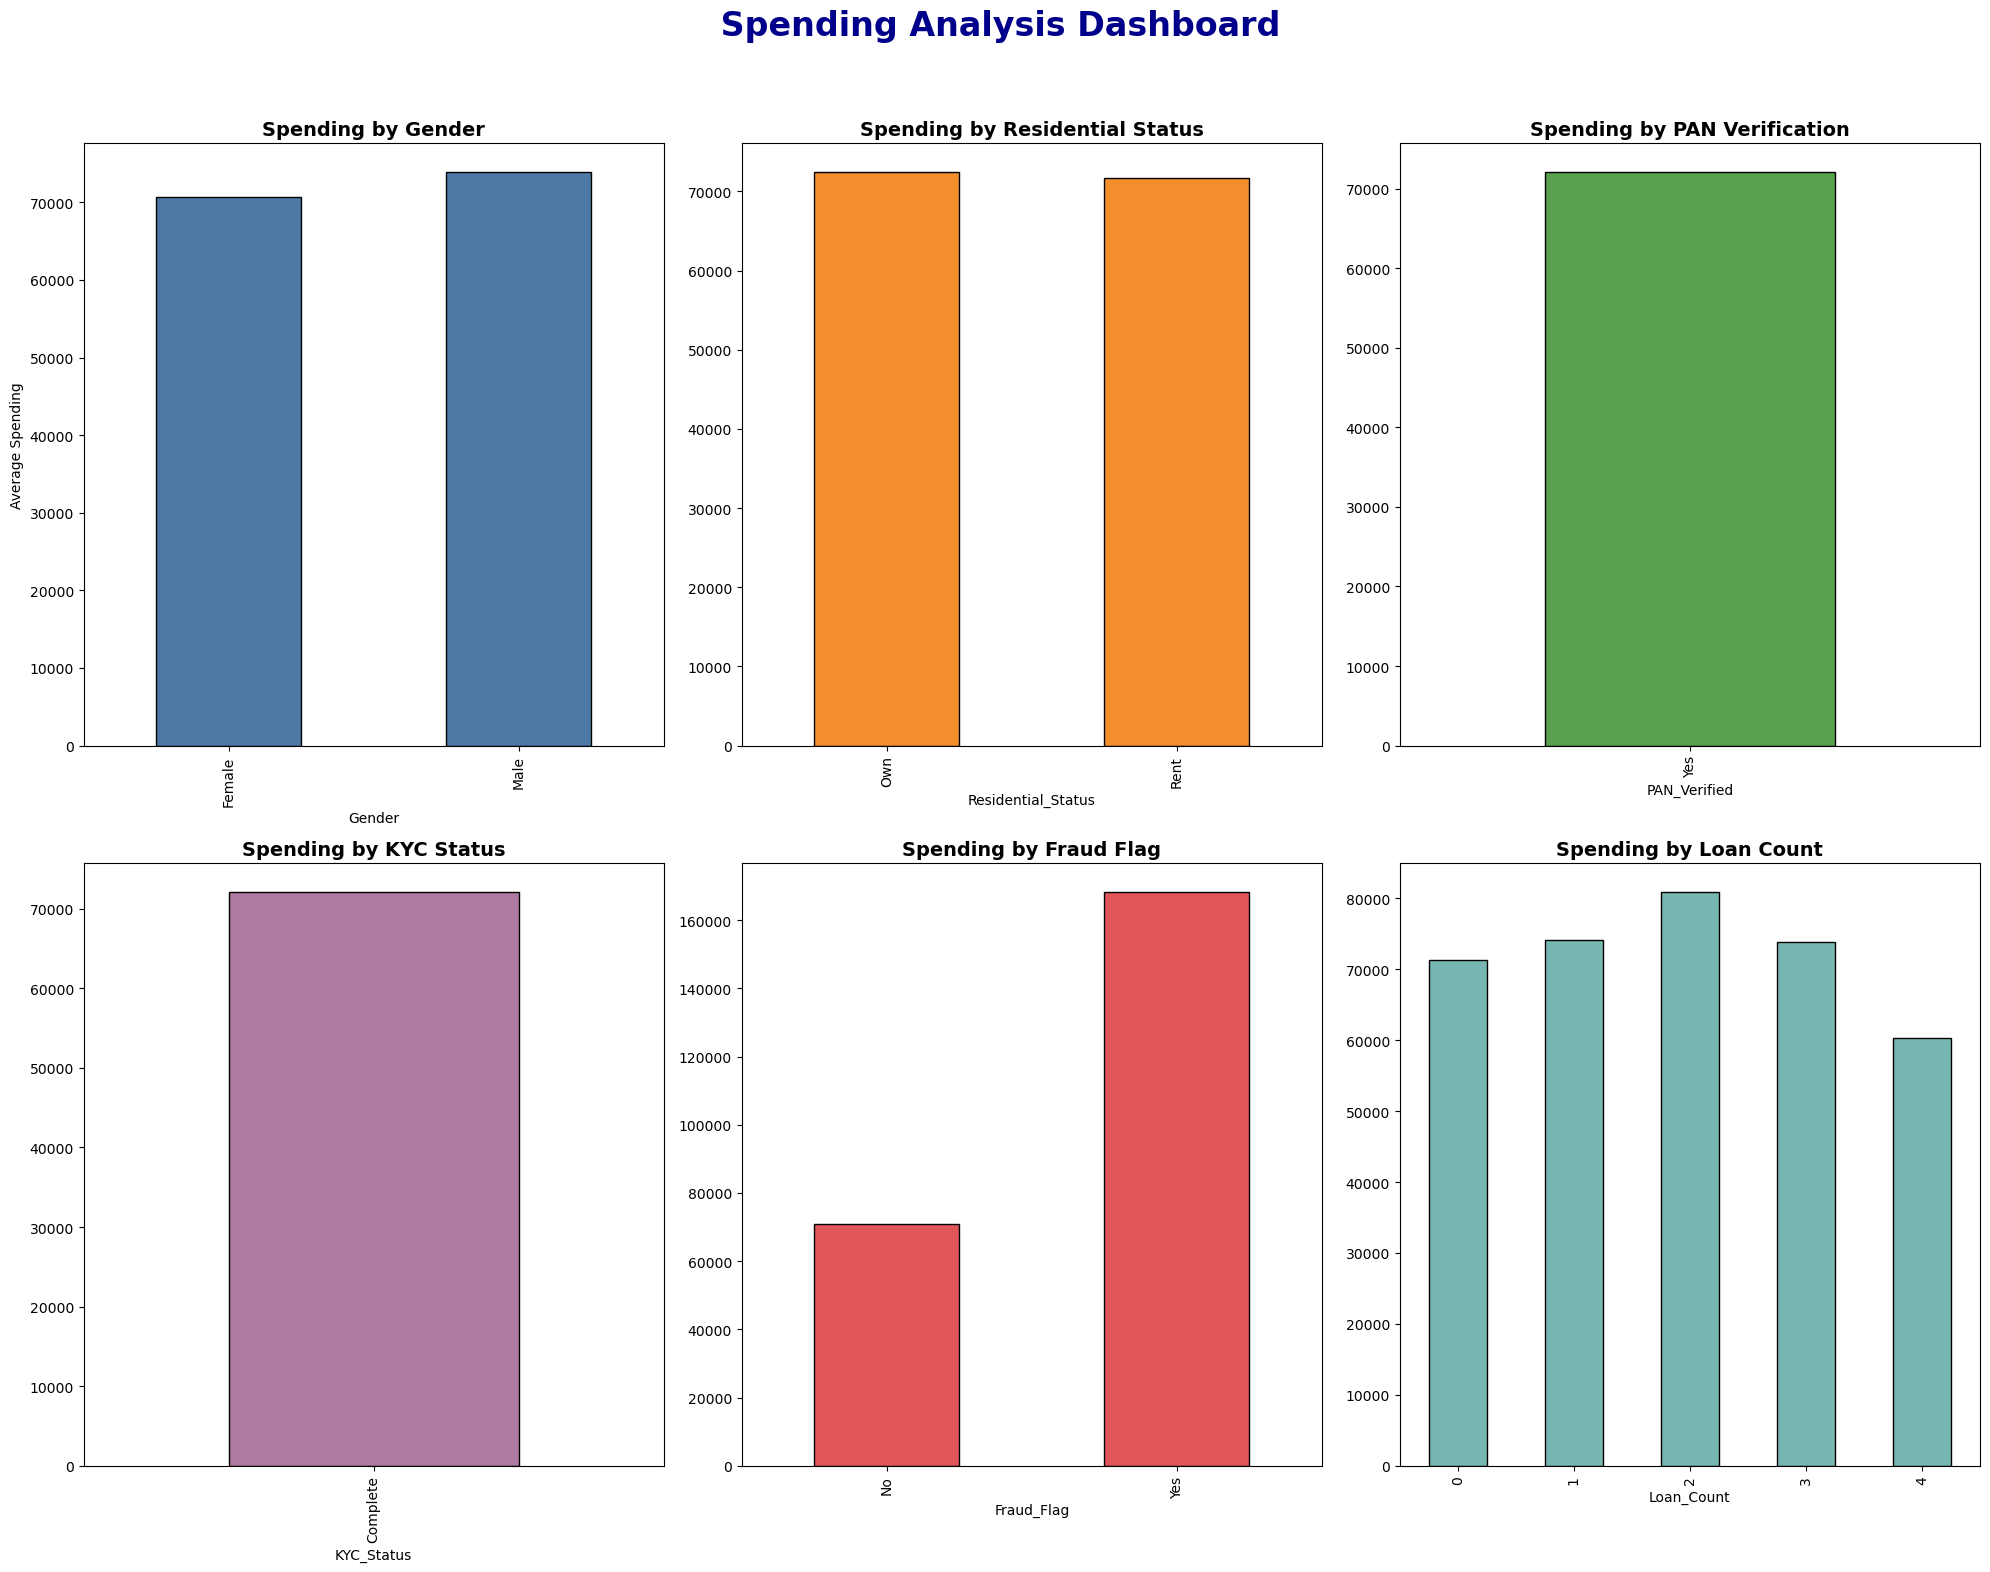

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(20,16))


fig.suptitle(" Spending Analysis Dashboard",
             fontsize=24,
             fontweight='bold',
             color='darkblue')

# 1. Spending by Gender
gender = final_df.groupby('Gender')['Avg_Monthly_Spending'].mean()
gender.plot(kind='bar', ax=axes[0,0],  color='#4E79A7', edgecolor='black')
axes[0,0].set_title("Spending by Gender",fontsize=14 , fontweight='bold')
axes[0,0].set_ylabel("Average Spending")

# 2. Spending by Residential Status
res = final_df.groupby('Residential_Status')['Avg_Monthly_Spending'].mean()
res.plot(kind='bar', ax=axes[0,1], color='#F28E2B', edgecolor='black')
axes[0,1].set_title("Spending by Residential Status",fontsize=14 , fontweight='bold')

# 3. Spending by PAN Verification
pan = final_df.groupby('PAN_Verified')['Avg_Monthly_Spending'].mean()
pan.plot(kind='bar', ax=axes[0,2], color='#59A14F', edgecolor='black')
axes[0,2].set_title("Spending by PAN Verification",fontsize=14 , fontweight='bold')

# 4. Spending by KYC Status
kyc = final_df.groupby('KYC_Status')['Avg_Monthly_Spending'].mean()
kyc.plot(kind='bar', ax=axes[1,0], color='#AF7AA1', edgecolor='black' )
axes[1,0].set_title("Spending by KYC Status",fontsize=14 , fontweight='bold')

# 5. Spending by Fraud Flag
fraud = final_df.groupby('Fraud_Flag')['Avg_Monthly_Spending'].mean()
fraud.plot(kind='bar', ax=axes[1,1], color='#E15759', edgecolor='black' )
axes[1,1].set_title("Spending by Fraud Flag",fontsize=14 , fontweight='bold')

# 6. Spending by Loan Count
loan = final_df.groupby('Loan_Count')['Avg_Monthly_Spending'].mean()
loan.plot(kind='bar', ax=axes[1,2], color='#76B7B2', edgecolor='black')
axes[1,2].set_title("Spending by Loan Count",fontsize=14 , fontweight='bold')

    
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

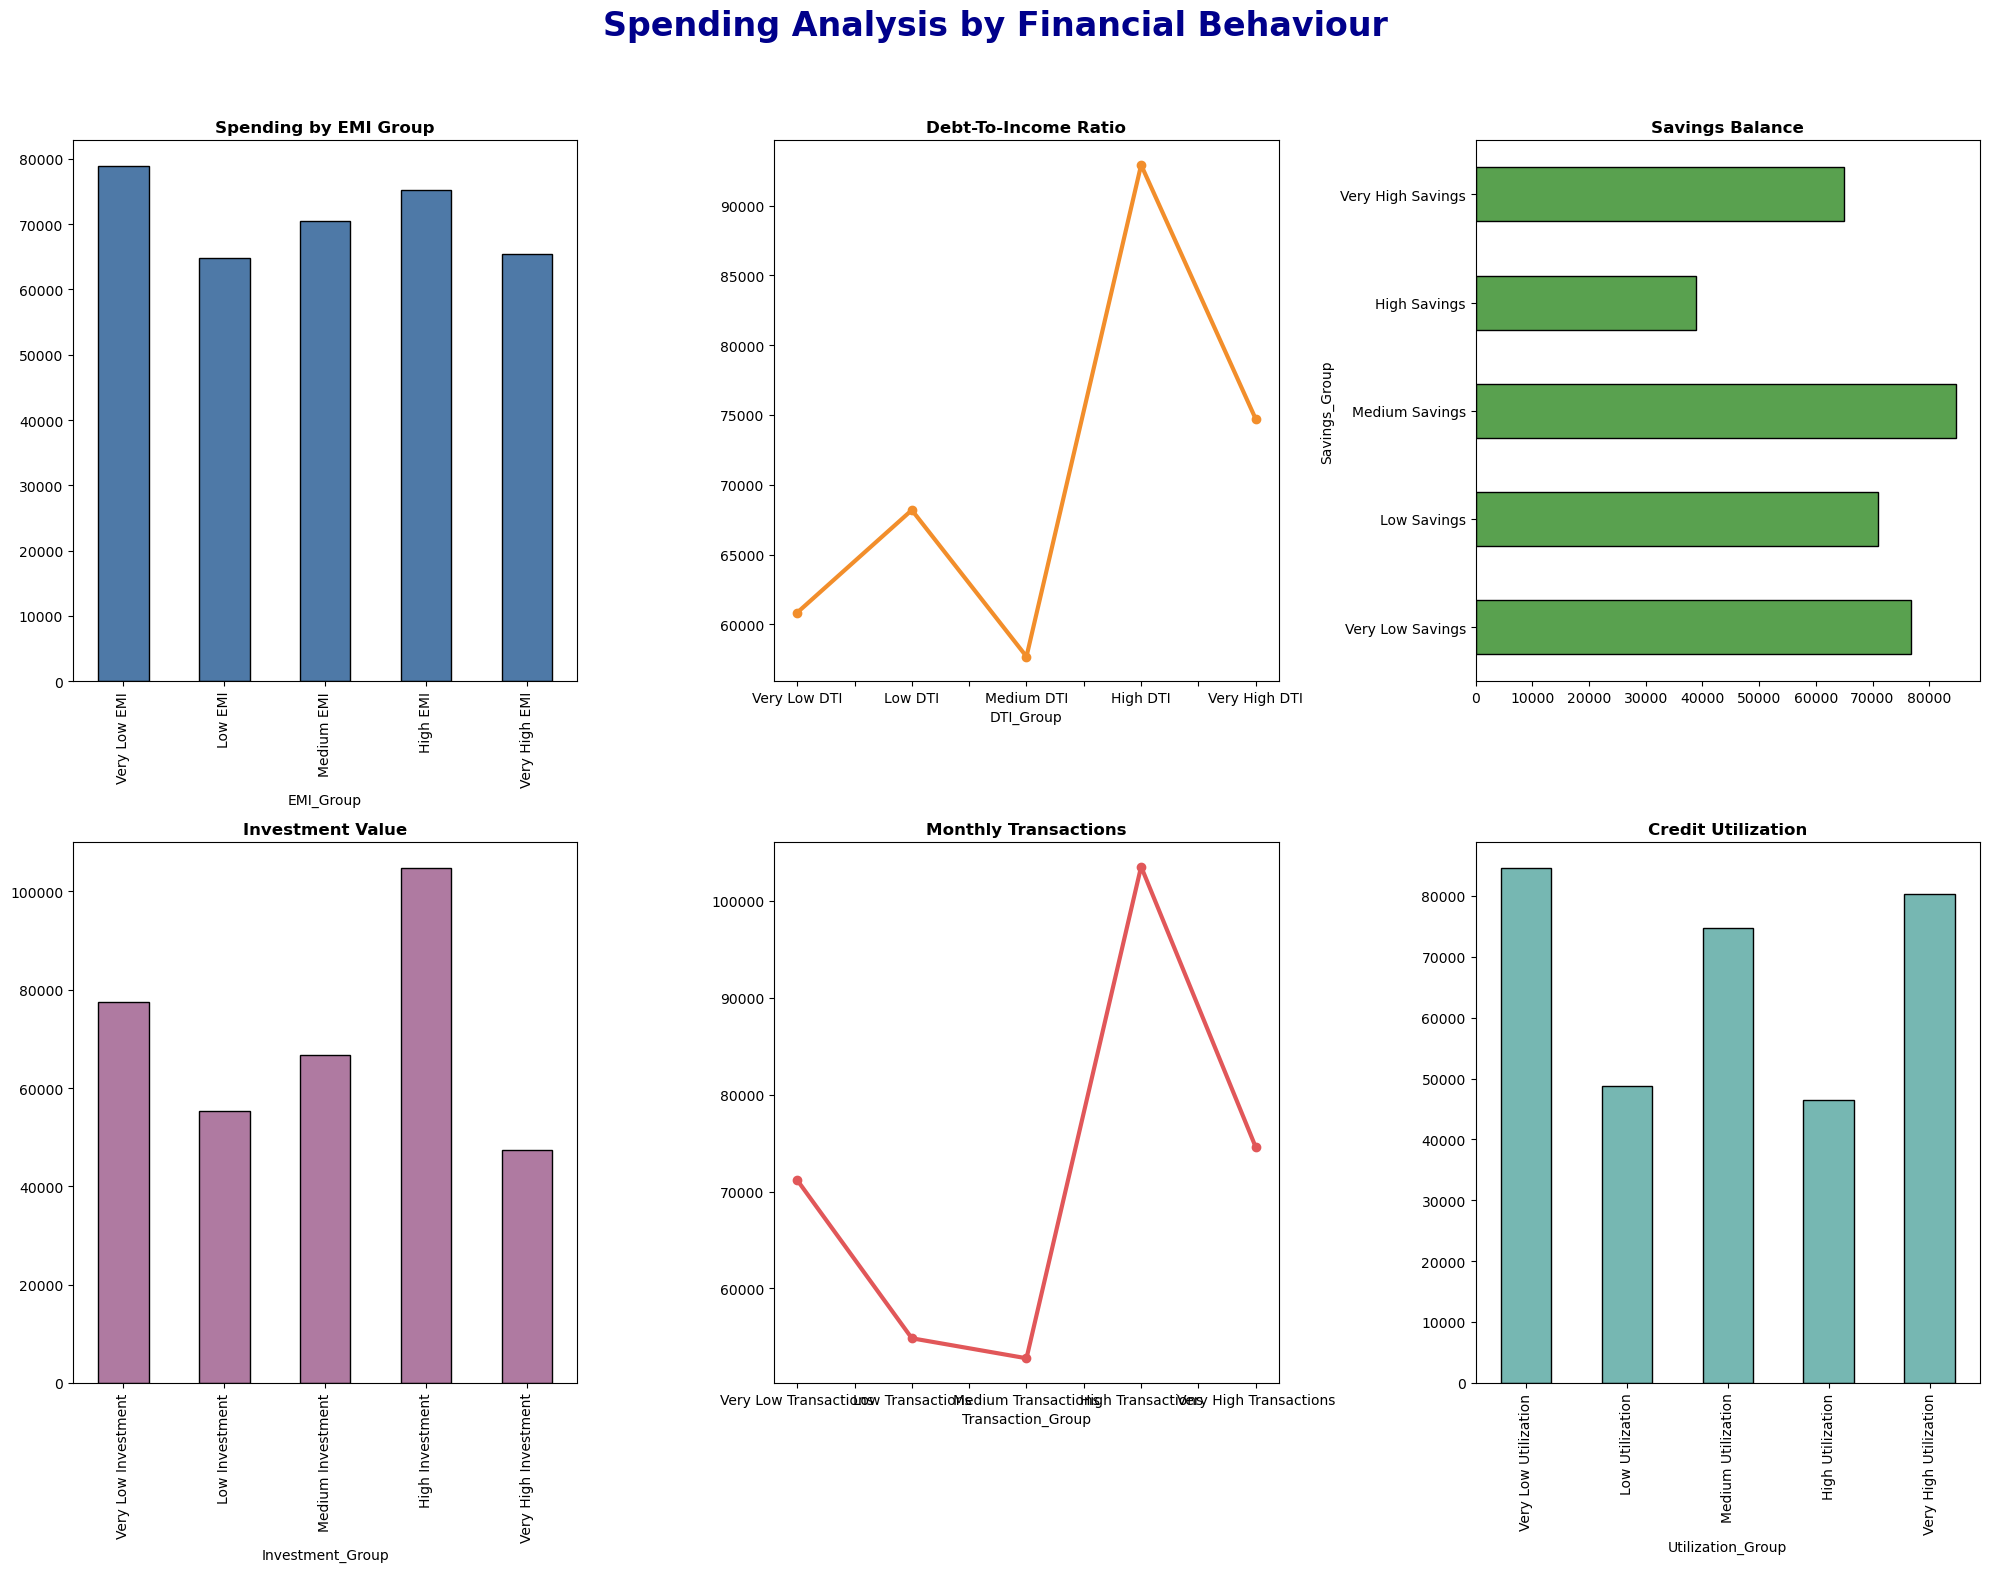

In [27]:
fig, axes = plt.subplots(2,3,figsize=(20,16))

fig.suptitle("Spending Analysis by Financial Behaviour",
             fontsize=24,
             fontweight='bold',
             color='darkblue')

# 1. EMI
emi = final_df.groupby('EMI_Group', observed=True)['Avg_Monthly_Spending'].mean()
emi.plot(kind='bar',ax=axes[0,0],color='#4E79A7',edgecolor='black')
axes[0,0].set_title("Spending by EMI Group",fontweight='bold')

# 2. Debt To Income Ratio
dti = final_df.groupby('DTI_Group', observed=True)['Avg_Monthly_Spending'].mean()
dti.plot(kind='line',marker='o',linewidth=3,color='#F28E2B',ax=axes[0,1])
axes[0,1].set_title("Debt-To-Income Ratio",fontweight='bold')

# 3. Savings Balance
saving = final_df.groupby('Savings_Group', observed=True)['Avg_Monthly_Spending'].mean()

saving.plot(kind='barh',color='#59A14F',edgecolor='black',ax=axes[0,2])
axes[0,2].set_title("Savings Balance",fontweight='bold')

# 4. Investment Value
invest = final_df.groupby('Investment_Group', observed=True)['Avg_Monthly_Spending'].mean()
invest.plot(kind='bar',color='#AF7AA1',edgecolor='black',ax=axes[1,0])
axes[1,0].set_title("Investment Value",fontweight='bold')

# 5. Monthly Transactions
tran = final_df.groupby('Transaction_Group', observed=True)['Avg_Monthly_Spending'].mean()

tran.plot(kind='line',marker='o',linewidth=3,color='#E15759',ax=axes[1,1])
axes[1,1].set_title("Monthly Transactions",fontweight='bold')

# 6. Credit Utilization
util = final_df.groupby('Utilization_Group', observed=True)['Avg_Monthly_Spending'].mean()

util.plot(kind='bar',color='#76B7B2',edgecolor='black',ax=axes[1,2])

axes[1,2].set_title("Credit Utilization",fontweight='bold')


plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

In [19]:
# EMI Group
df['EMI_Group'] = pd.cut(df['EMI_Per_Month'],bins=5,labels=['Very Low EMI','Low EMI','Medium EMI','High EMI','Very High EMI'])

In [20]:
# Debt-to-Income Ratio Group
df['DTI_Group'] = pd.cut(df['Debt_To_Income_Ratio'],bins=5,labels=['Very Low DTI','Low DTI','Medium DTI','High DTI','Very High DTI'])

In [21]:
# Savings Balance Group
df['Savings_Group'] = pd.cut(df['Savings_Balance'],bins=5,labels=['Very Low Savings','Low Savings','Medium Savings','High Savings','Very High Savings'])

In [22]:
# Investment Value Group
df['Investment_Group'] = pd.cut(df['Investment_Value'],bins=5,labels=['Very Low Investment','Low Investment','Medium Investment','High Investment','Very High Investment'])

In [23]:
# Monthly Transactions Group
df['Transaction_Group'] = pd.cut(df['Avg_Monthly_Transactions'],bins=5,labels=['Very Low Transactions','Low Transactions','Medium Transactions','High Transactions','Very High Transactions'])

In [24]:
# Credit Utilization Group
df['Utilization_Group'] = pd.cut(df['Credit_Utilization'],bins=5,labels=['Very Low Utilization','Low Utilization','Medium Utilization','High Utilization','Very High Utilization'])